### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [54]:
#Reading the dataset from the GitHub repository
url = 'https://raw.githubusercontent.com/ashrivastav33/data/refs/heads/main/coupons.csv'
coupon_df = pd.read_csv(url)

In [55]:
coupon_df.head()

coupon_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [4]:
coupon_df.describe()

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12684.000000,12684.000000,12684.0,12684.000000,12684.000000,12684.000000,12684.000000,12684.000000
mean,63.301798,0.414144,1.0,0.561495,0.119126,0.214759,0.785241,0.568433
std,19.154486,0.492593,0.0,0.496224,0.323950,0.410671,0.410671,0.495314
min,30.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


2. Investigate the dataset for missing or problematic data.

In [5]:
# Check for missing values
missing_values = coupon_df.isnull().sum()
print("Missing values per column:")
print(missing_values)

# Calculate percentage of missing values
missing_percentage = (coupon_df.isnull().sum() / len(coupon_df)) * 100
print("\nPercentage of missing values per column:")
print(missing_percentage)

# Investigate problematic data (e.g., inconsistent entries or data types)
# Display unique values for object type columns to identify potential issues
for col in coupon_df.select_dtypes(include='object').columns:
    print(f"\nUnique values for column '{col}':")
    print(coupon_df[col].unique())

Missing values per column:
destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

Percentage of missing values per column:
destination              0.000000
passanger                0.000000
weather                  0.000000
temperature              0.000000
ti

In [7]:
print(coupon_df.isnull().sum())

coupon_df.groupby('gender').count()

coupon_df.coupon.value_counts().sort_values(ascending=False)


destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64


,count
coupon,
Coffee House,3996
Restaurant(<20),2786
Carry out & Take away,2393
Bar,2017
Restaurant(20-50),1492


3. Decide what to do about your missing data -- drop, replace, other...

In [8]:
# Drop the 'car' column due to high percentage of missing values
coupon_df.drop('car', axis=1, inplace=True)

# Fill missing values in remaining columns with the mode
for col in ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']:
    coupon_df[col].fillna(coupon_df[col].mode()[0], inplace=True)

print("Missing values after handling:")
print(coupon_df.isnull().sum())

Missing values after handling:
destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64


/tmp/ipython-input-2250018911.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  coupon_df[col].fillna(coupon_df[col].mode()[0], inplace=True)


4. What proportion of the total observations chose to accept the coupon?



In [9]:
# Calculate the proportion of accepted coupons
accepted_proportion = coupon_df['Y'].mean()

print(f"Proportion of accepted coupons: {accepted_proportion:.2f}")

Proportion of accepted coupons: 0.57


5. Use a bar plot to visualize the `coupon` column.

6. Use a histogram to visualize the temperature column.

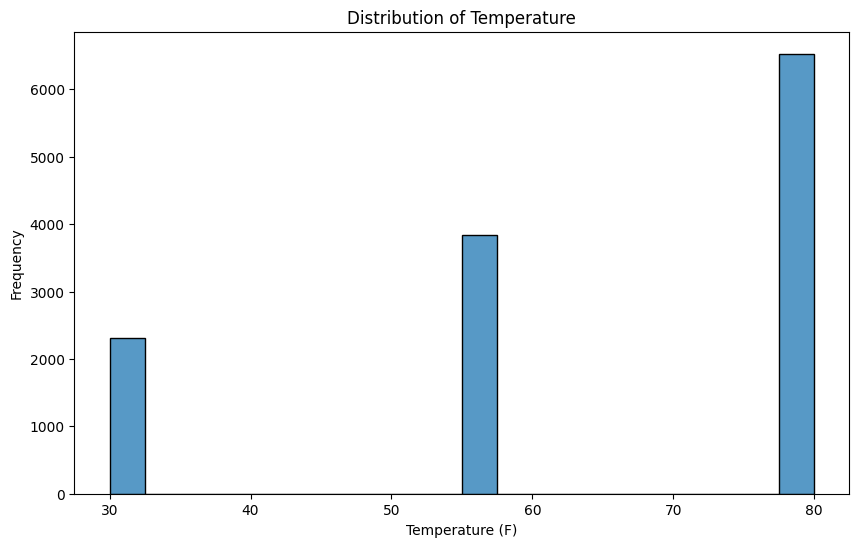

In [12]:
# Use a histogram to visualize the temperature column
plt.figure(figsize=(10, 6))
sns.histplot(data=coupon_df, x='temperature', bins=20, kde=False)
plt.title('Distribution of Temperature')
plt.xlabel('Temperature (F)')
plt.ylabel('Frequency')
plt.show()

<Axes: >

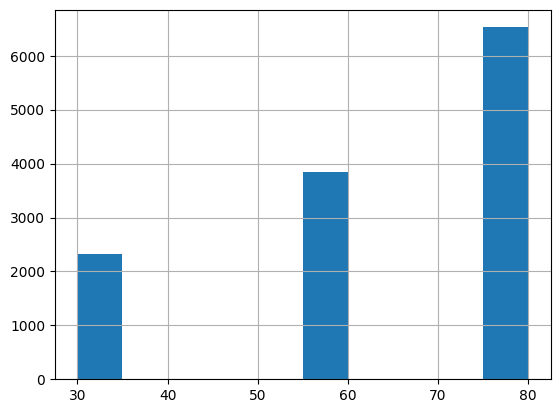

In [13]:
coupon_df['temperature'].hist()




#sns.boxplot(x='education', y='income', data=data)
#plt.title("Boxplot of Continuous by Categorical")
#plt.xticks(rotation=90)
#plt.show()

In [14]:
coupon_df.groupby('coupon')

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [15]:
# Create a new DataFrame that contains just the bar coupons.
bar_coupons = coupon_df[coupon_df['coupon'] == 'Bar']
bar_coupons.describe().value_counts()

temperature  has_children  toCoupon_GEQ5min  toCoupon_GEQ15min  toCoupon_GEQ25min  direction_same  direction_opp  Y          
17.950408    0.495723      0.0               0.472677           0.434754           0.406854        0.406854       0.491958       1
30.000000    0.000000      1.0               0.000000           0.000000           0.000000        0.000000       0.000000       1
55.000000    0.000000      1.0               0.000000           0.000000           0.000000        1.000000       0.000000       1
                                             1.000000           0.000000           0.000000        1.000000       0.000000       1
57.590481    0.433813      1.0               0.663361           0.252851           0.209222        0.790778       0.410015       1
80.000000    1.000000      1.0               1.000000           1.000000           0.000000        1.000000       1.000000       1
                                                                                   1.000000        1.000000       1.000000       1
2017.000000  2017.000000   2017.0            2017.000000        2017.000000        2017.000000     2017.000000    2017.000000    1
Name: count, dtype: int64

2. What proportion of bar coupons were accepted?


In [16]:
# --------------------------------------------
# Calculate the proportion of bar coupons accepted
# --------------------------------------------
bar_accepted_proportion = bar_coupons['Y'].mean()

print(f"Proportion of accepted bar coupons: {bar_accepted_proportion:.2f}")

Proportion of accepted bar coupons: 0.41


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


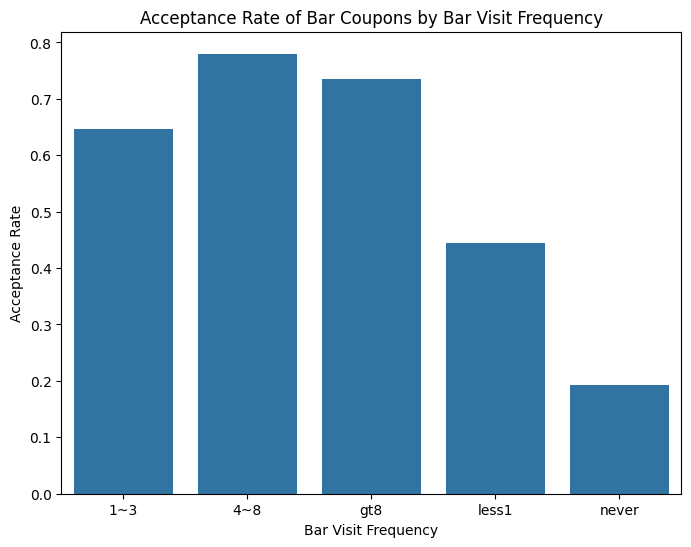

In [17]:
#bar_coupons['Bar'].value_counts()

bar_acceptance_by_frequency = bar_coupons.groupby('Bar')['Y'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(x='Bar', y='Y', data=bar_acceptance_by_frequency)
plt.title('Acceptance Rate of Bar Coupons by Bar Visit Frequency')
plt.xlabel('Bar Visit Frequency')
plt.ylabel('Acceptance Rate')
plt.show()


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [50]:
#Get Unique age values
unique_age = bar_coupons['age'].unique()
drivers_visiting_bar_more_than_once_a_month = bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])
unique_age
age_over_25_filter = bar_coupons['age'].isin(['26', '31', '36', '41','46','50plus'])
unique_age
bar_acceptance_by_frequency_above25 = bar_coupons.groupby(drivers_visiting_bar_more_than_once_a_month & age_over_25_filter)['Y'].mean().reset_index()
bar_acceptance_by_frequency_above25



,index,Y
0,False,0.335003
1,True,0.695238


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [52]:
#Explores Acceptance Rate of compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry

#Used the below code to get unique passanger values
unique_passenger = bar_coupons['passanger'].value_counts()

#Used the below code to get unique occupation values
unique_occupation = bar_coupons['occupation'].value_counts()

# Drivers with occupations other than farming, fishing, or forestry"
drivers_oc_not_farming_fishing_forestry = ~bar_coupons['occupation'].isin(['Farming Fishing & Forestry'])

#Drivers visiting Bar more than once a month has been defined above section
drivers_visiting_bar_more_than_once_a_month

# Value of passsengers who aren't kids
drivers_with_adult_passenger_only = bar_coupons['passanger'] != 'Kid(s)'

# Creating group of drivers who visit bar more than once a month + Have No kids as passenger + Not in occupation Farming, Fishing, Forestry
group_as_per_question = bar_coupons[drivers_visiting_bar_more_than_once_a_month & drivers_visiting_bar_more_than_once_a_month & drivers_visiting_bar_more_than_once_a_month]

# Creating a group for all other drivers
all_other_groups = bar_coupons[~(drivers_visiting_bar_more_than_once_a_month & drivers_visiting_bar_more_than_once_a_month & drivers_visiting_bar_more_than_once_a_month)]

# Calculate acceptance rates
acp_rate_group_as_per_question = group_as_per_question['Y'].mean()
acp_rate_all_other_groups = all_other_groups['Y'].mean()

print(f"Acceptance rate for drivers who visit bar more than once a month + Have No kids as passenger + Not in occupation Farming, Fishing, Forestry: {acp_rate_group_as_per_question:.2f}")
print(f"Acceptance rate for all other drivers: {acp_rate_all_other_groups:.2f}")


Acceptance rate for ddrivers who visit bar more than once a month + Have No kids as passenger + Not in occupation Farming, Fishing, Forestry: 0.69
Acceptance rate for all other drivers: 0.29


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



Acceptance rate for drivers meeting any of the conditions: 0.61
Acceptance rate for all other drivers: 0.30


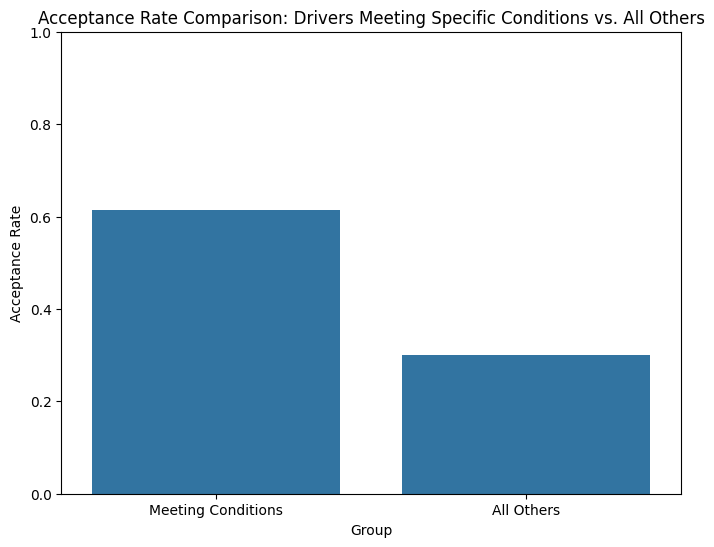

In [20]:
# Define the conditions for the first group
condition_1 = (
    bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8']) &
    (bar_coupons['passanger'] != 'Kid(s)') &
    (bar_coupons['maritalStatus'] != 'Widowed')
)

# Define the conditions for the second group
condition_2 = (
    bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8']) &
    bar_coupons['age'].isin(['below 21', '21 to 25'])
)

# Define the conditions for the third group
condition_3 = (
    bar_coupons['RestaurantLessThan20'].isin(['4~8', 'gt8']) &
    bar_coupons['income'].isin(['Less than $12500', '$12500 - $24999', '$25000 - $37499'])
)

# Combine the conditions using the OR operator
combined_condition = condition_1 | condition_2 | condition_3

# Create a group for drivers who meet any of the combined conditions
group_e = bar_coupons[combined_condition]

# Create a group for all other drivers
group_f = bar_coupons[~combined_condition]

# Calculate acceptance rates for each group
acceptance_rate_group_e = group_e['Y'].mean()
acceptance_rate_group_f = group_f['Y'].mean()

print(f"Acceptance rate for drivers meeting any of the conditions: {acceptance_rate_group_e:.2f}")
print(f"Acceptance rate for all other drivers: {acceptance_rate_group_f:.2f}")

# Create a DataFrame for visualization
comparison_data_3 = pd.DataFrame({
    'Group': ['Meeting Conditions', 'All Others'],
    'Acceptance Rate': [acceptance_rate_group_e, acceptance_rate_group_f]
})

# Create a bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='Group', y='Acceptance Rate', data=comparison_data_3)
plt.title('Acceptance Rate Comparison: Drivers Meeting Specific Conditions vs. All Others')
plt.ylabel('Acceptance Rate')
plt.ylim(0, 1) # Set y-axis limit from 0 to 1 for proportion
plt.show()

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

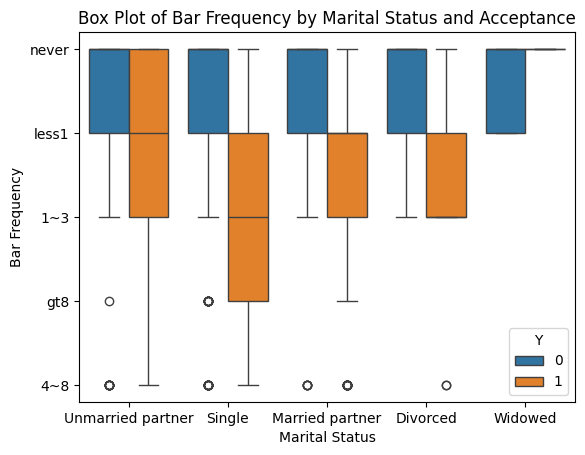

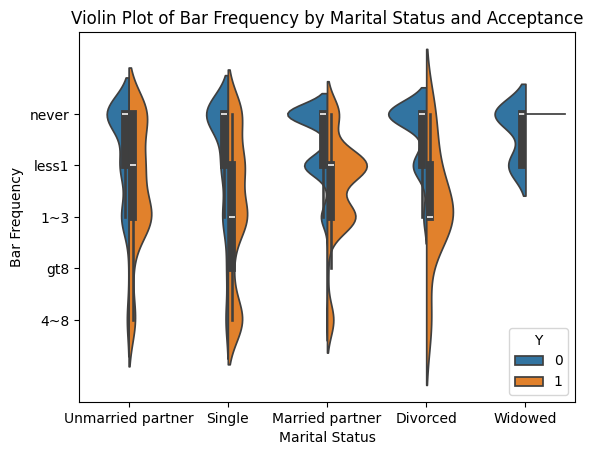

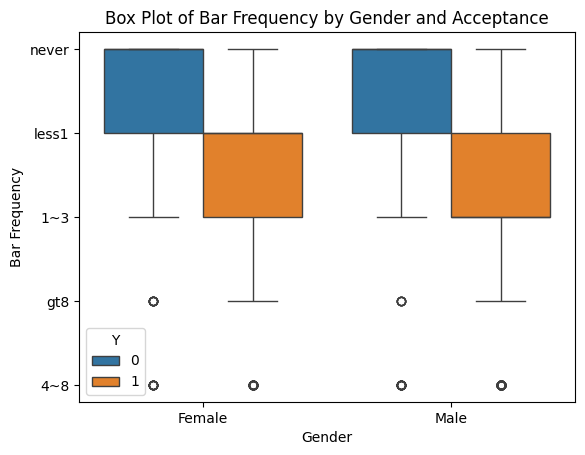

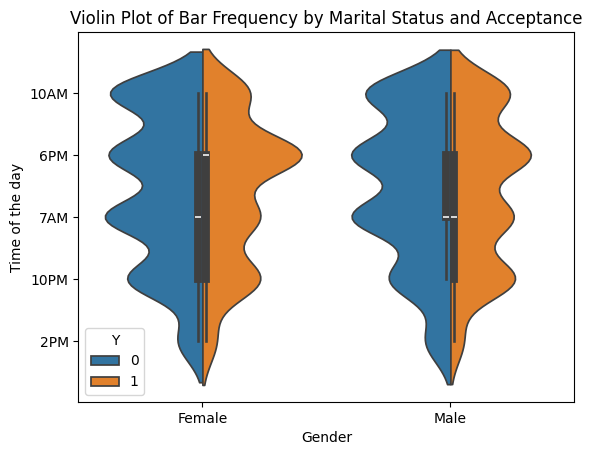

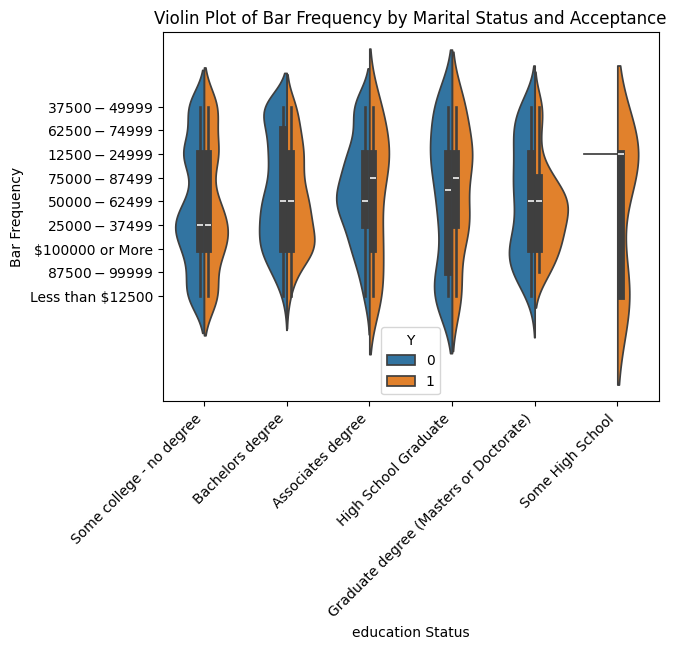

In [25]:
#sns.histplot(data=bar_coupons, x='age', y='Bar', hue='Y')

sns.boxplot(x='maritalStatus', y='Bar', hue='Y', data=bar_coupons)
plt.title('Box Plot of Bar Frequency by Marital Status and Acceptance')
plt.xlabel('Marital Status')
plt.ylabel('Bar Frequency')
plt.show()
sns.violinplot(x='maritalStatus', y='Bar', hue='Y', data=bar_coupons, split=True)
plt.title('Violin Plot of Bar Frequency by Marital Status and Acceptance')
plt.xlabel('Marital Status')
plt.ylabel('Bar Frequency')
plt.show()

sns.boxplot(x='gender', y='Bar', hue='Y', data=bar_coupons)
plt.title('Box Plot of Bar Frequency by Gender and Acceptance')
plt.xlabel('Gender')
plt.ylabel('Bar Frequency')
plt.show()

sns.violinplot(x='gender', y='time', hue='Y', data=bar_coupons, split=True)
plt.title('Violin Plot of Bar Frequency by Marital Status and Acceptance')
plt.xlabel('Gender')
plt.ylabel('Time of the day')
plt.show()

sns.violinplot(x='education', y='income', hue='Y', data=bar_coupons, split=True)
plt.title('Violin Plot of Bar Frequency by Marital Status and Acceptance')
plt.xlabel('education Status')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Bar Frequency')
plt.show()




### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

Investagting Coffee house

In [22]:
# Create a new DataFrame that contains just the bar coupons.
coffee_house_coupons = coupon_df[coupon_df['coupon'] == 'Coffee House']
coffee_house_coupons.describe().value_counts()


coffee_house_coupons['expiration'] = coffee_house_coupons['expiration'].replace('2h', 2)

coffee_house_coupons['expiration'] = coffee_house_coupons['expiration'].replace('1d', 24)

coffee_house_coupons['expiration'].astype(int)

coffee_house_coupons.info()

coffee_house_coupons.head()

<class 'pandas.core.frame.DataFrame'>
Index: 3996 entries, 1 to 12681
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           3996 non-null   object
 1   passanger             3996 non-null   object
 2   weather               3996 non-null   object
 3   temperature           3996 non-null   int64 
 4   time                  3996 non-null   object
 5   coupon                3996 non-null   object
 6   expiration            3996 non-null   int64 
 7   gender                3996 non-null   object
 8   age                   3996 non-null   object
 9   maritalStatus         3996 non-null   object
 10  has_children          3996 non-null   int64 
 11  education             3996 non-null   object
 12  occupation            3996 non-null   object
 13  income                3996 non-null   object
 14  Bar                   3996 non-null   object
 15  CoffeeHouse           3996 non-null   obje

/tmp/ipython-input-3084851432.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coffee_house_coupons['expiration'] = coffee_house_coupons['expiration'].replace('2h', 2)
/tmp/ipython-input-3084851432.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  coffee_house_coupons['expiration'] = coffee_house_coupons['expiration'].replace('1d', 24)
/tmp/ipython-input-3084851432.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inste

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,0,1,0
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,24,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,1
15,Home,Alone,Sunny,80,6PM,Coffee House,2,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,0,1,0


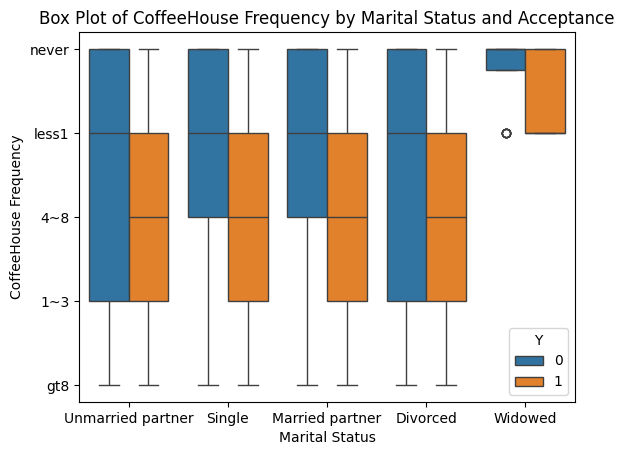

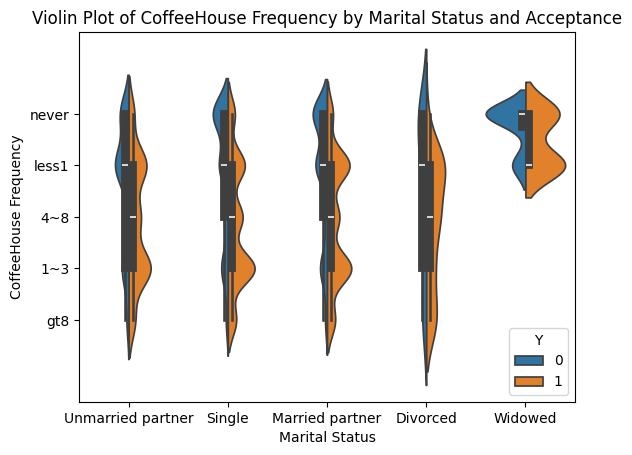

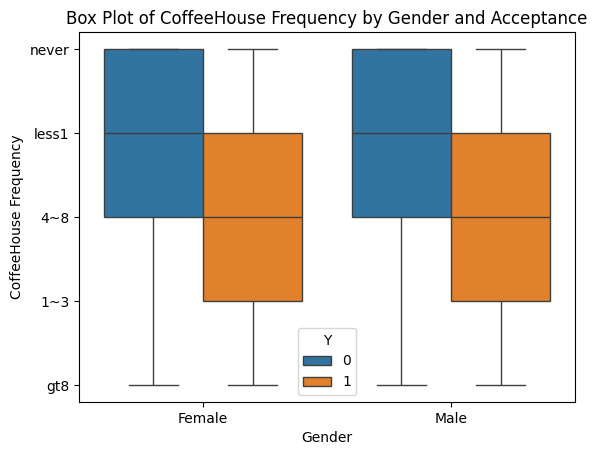

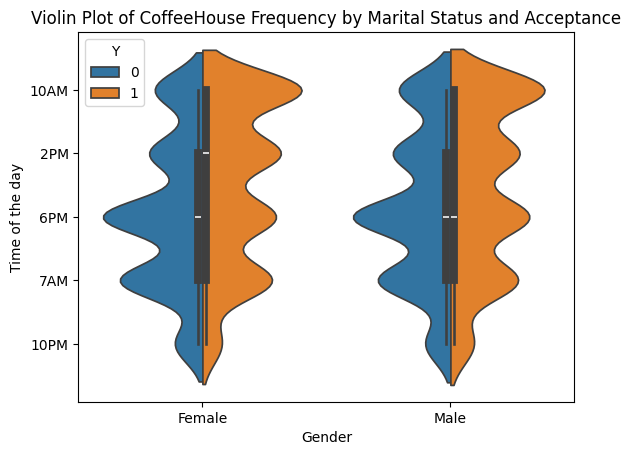

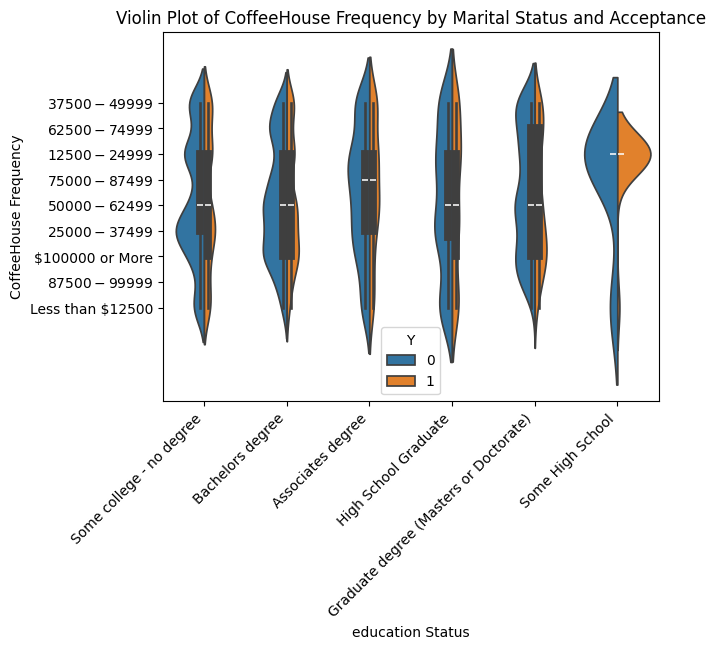

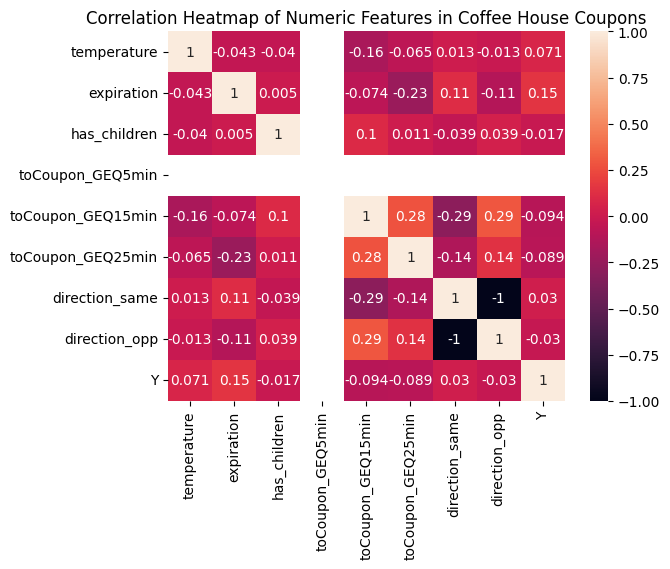

In [27]:
#sns.histplot(data=bar_coupons, x='age', y='Bar', hue='Y')



sns.boxplot(x='maritalStatus', y='CoffeeHouse', hue='Y', data=coffee_house_coupons)
plt.title('Box Plot of CoffeeHouse Frequency by Marital Status and Acceptance')
plt.xlabel('Marital Status')
plt.ylabel('CoffeeHouse Frequency')
plt.show()
sns.violinplot(x='maritalStatus', y='CoffeeHouse', hue='Y', data=coffee_house_coupons, split=True)
plt.title('Violin Plot of CoffeeHouse Frequency by Marital Status and Acceptance')
plt.xlabel('Marital Status')
plt.ylabel('CoffeeHouse Frequency')
plt.show()

sns.boxplot(x='gender', y='CoffeeHouse', hue='Y', data=coffee_house_coupons)
plt.title('Box Plot of CoffeeHouse Frequency by Gender and Acceptance')
plt.xlabel('Gender')
plt.ylabel('CoffeeHouse Frequency')
plt.show()

sns.violinplot(x='gender', y='time', hue='Y', data=coffee_house_coupons, split=True)
plt.title('Violin Plot of CoffeeHouse Frequency by Marital Status and Acceptance')
plt.xlabel('Gender')
plt.ylabel('Time of the day')
plt.show()

sns.violinplot(x='education', y='income', hue='Y', data=coffee_house_coupons, split=True)
plt.title('Violin Plot of CoffeeHouse Frequency by Marital Status and Acceptance')
plt.xlabel('education Status')
plt.xticks(rotation=45, ha='right')
plt.ylabel('CoffeeHouse Frequency')
plt.show()



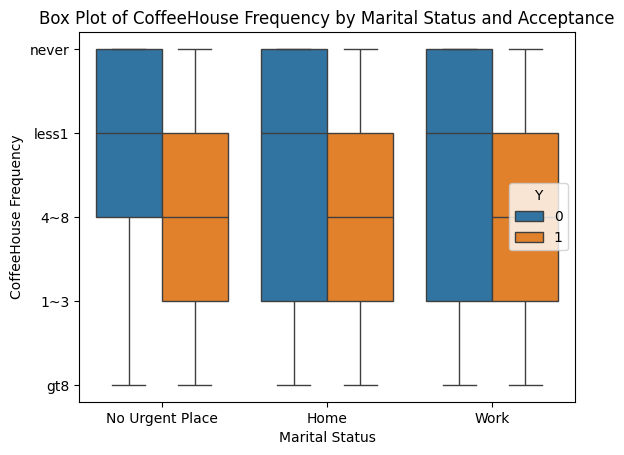

In [28]:
sns.boxplot(x='destination', y='CoffeeHouse', hue='Y', data=coffee_house_coupons)
plt.title('Box Plot of CoffeeHouse Frequency by Marital Status and Acceptance')
plt.xlabel('Marital Status')
plt.ylabel('CoffeeHouse Frequency')
plt.show()

([0, 1, 2],
 [Text(0, 0, 'Home'), Text(1, 0, 'No Urgent Place'), Text(2, 0, 'Work')])

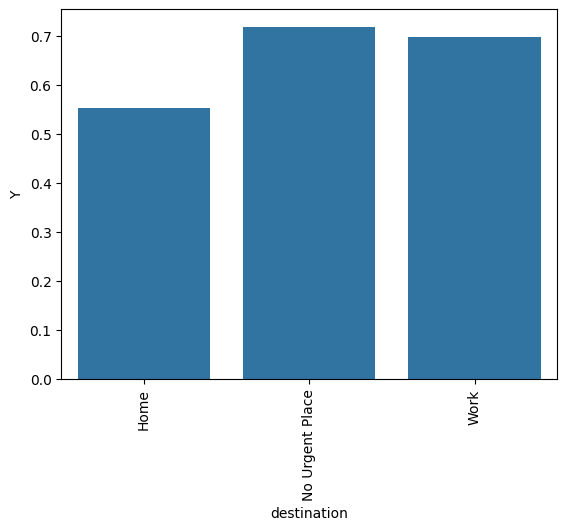

In [47]:
ocmean=data_oc.groupby(['destination'])[['Y']].mean().reset_index()

sns.barplot(x='destination', y='Y',data=ocmean)
plt.xticks(rotation=90)

<Axes: xlabel='time', ylabel='Y'>

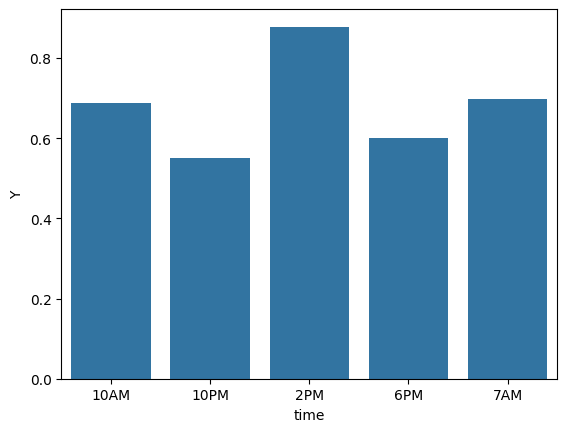

In [45]:
oc_list = ['Healthcare Practitioners & Technical', 'Building & Grounds Cleaning & Meaintenance']
data_oc = coupon_df.query('occupation in @oc_list')
ocmean=data_oc.groupby(['time'])[['Y']].mean().reset_index()
sns.barplot(data=ocmean, x = 'time', y='Y')